#**UTS BUSINESS INTELLIGENCE**




### KELOMPOK 10:
- Grace Vies Angel (2409116005)
- Angela Caroline Budiman (2409116008)
- Zahraturramadhani (2409116014)
- Muhammad Fachri (2409116017)

####**ETL (Extract, Transform, Load)**

#####**Extract**

In [ ]:
import pandas as pd

In [ ]:
# Load data

df_raw = pd.read_csv('/content/drive/MyDrive/praktikum/Amazon Sale Report.csv')
df_raw.head()

/tmp/ipykernel_459/3698446055.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('/content/drive/MyDrive/praktikum/Amazon Sale Report.csv')


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


#####**Transform**

In [ ]:
# Cek data kosong
df_raw.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
# Hapus data kosong

df_clean = df_raw.dropna().copy()

In [ ]:
# Cek ulang data

df_clean.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
# Cek tipe data

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19379 entries, 49051 to 128891
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               19379 non-null  int64  
 1   Order ID            19379 non-null  object 
 2   Date                19379 non-null  object 
 3   Status              19379 non-null  object 
 4   Fulfilment          19379 non-null  object 
 5   Sales Channel       19379 non-null  object 
 6   ship-service-level  19379 non-null  object 
 7   Style               19379 non-null  object 
 8   SKU                 19379 non-null  object 
 9   Category            19379 non-null  object 
 10  Size                19379 non-null  object 
 11  ASIN                19379 non-null  object 
 12  Courier Status      19379 non-null  object 
 13  Qty                 19379 non-null  int64  
 14  currency            19379 non-null  object 
 15  Amount              19379 non-null  float64
 16  ship

In [ ]:
# Lihat statistik

df_clean.describe()

,index,Qty,Amount,ship-postal-code
count,19379.000000,19379.000000,19379.000000,19379.000000
mean,86650.405542,1.004799,673.245162,464618.933743
std,22204.535858,0.082081,287.866514,191536.937504
min,49051.000000,1.000000,0.000000,110001.000000
25%,67813.000000,1.000000,471.000000,380058.000000
50%,83317.000000,1.000000,678.000000,500032.000000
75%,105153.500000,1.000000,786.000000,600039.000000
max,128891.000000,5.000000,2796.000000,855107.000000


In [ ]:
# CEK KOLOM SEBELUM RENAME
print("=== BEFORE RENAME ===")
print(df_clean.columns)

=== BEFORE RENAME ===
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')


In [ ]:
# RENAME KOLOM

df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

In [ ]:
# CEK KOLOM SETELAH RENAME
print("=== AFTER RENAME ===")
print(df_clean.columns)

=== AFTER RENAME ===
Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel_',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed:_22'],
      dtype='object')


In [ ]:
# CEK FORMAT TANGGAL SEBELUM DIUBAH
print("=== BEFORE DATE FORMAT ===")
print(df_clean['date'].head())
print(df_clean['date'].dtype)

=== BEFORE DATE FORMAT ===
49051    05-31-22
49077    05-31-22
49081    05-31-22
49082    05-31-22
49083    05-31-22
Name: date, dtype: object
object


In [ ]:
# UBAH FORMAT TANGGAL

df_clean['date'] = pd.to_datetime(df_clean['date'])

/tmp/ipykernel_459/1611508643.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date'] = pd.to_datetime(df_clean['date'])


In [ ]:
# CEK FORMAT TANGGAL SETELAH DIUBAH
print("=== AFTER DATE FORMAT ===")
print(df_clean['date'].head())
print(df_clean['date'].dtype)

=== AFTER DATE FORMAT ===
49051   2022-05-31
49077   2022-05-31
49081   2022-05-31
49082   2022-05-31
49083   2022-05-31
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
# CEK TIPE DATA AMOUNT SEBELUM DIUBAH
print("=== BEFORE CONVERT AMOUNT ===")
print(df_clean['amount'].head())
print(df_clean['amount'].dtype)

=== BEFORE CONVERT AMOUNT ===
49051    888.0
49077    371.0
49081    771.0
49082      0.0
49083    690.0
Name: amount, dtype: float64
float64


In [ ]:
# PASTIKAN HARGA ANGKA

df_clean['amount'] = pd.to_numeric(df_clean['amount'], errors='coerce')

In [ ]:
# CEK TIPE DATA AMOUNT SETELAH DIUBAH
print("=== AFTER CONVERT AMOUNT ===")
print(df_clean['amount'].head())
print(df_clean['amount'].dtype)

=== AFTER CONVERT AMOUNT ===
49051    888.0
49077    371.0
49081    771.0
49082      0.0
49083    690.0
Name: amount, dtype: float64
float64


In [ ]:
# CEK JUMLAH DATA SEBELUM HAPUS DUPLIKAT
print("=== BEFORE DROP DUPLICATES ===")
print("Jumlah data:", len(df_clean))
print("Jumlah data duplikat:", df_clean.duplicated().sum())

=== BEFORE DROP DUPLICATES ===
Jumlah data: 19379
Jumlah data duplikat: 0


In [ ]:
# HAPUS DATA DUPLIKAT

df_clean = df_clean.drop_duplicates()

In [ ]:
# CEK JUMLAH DATA SETELAH HAPUS DUPLIKAT
print("=== AFTER DROP DUPLICATES ===")
print("Jumlah data:", len(df_clean))
print("Jumlah data duplikat:", df_clean.duplicated().sum())

=== AFTER DROP DUPLICATES ===
Jumlah data: 19379
Jumlah data duplikat: 0


In [ ]:
# CEK KOLOM SEBELUM DITAMBAHKAN
print("=== BEFORE ADD NEW COLUMN ===")
print(df_clean.columns)

=== BEFORE ADD NEW COLUMN ===
Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel_',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed:_22'],
      dtype='object')


In [ ]:
# TAMBAH KOLOM BARU

df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

In [ ]:
# CEK KOLOM SETELAH DITAMBAHKAN
print("=== AFTER ADD NEW COLUMN ===")
print(df_clean[['date', 'year', 'month']].head())

=== AFTER ADD NEW COLUMN ===
            date  year  month
49051 2022-05-31  2022      5
49077 2022-05-31  2022      5
49081 2022-05-31  2022      5
49082 2022-05-31  2022      5
49083 2022-05-31  2022      5


In [ ]:
df_clean.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel_',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'fulfilled-by', 'unnamed:_22', 'year', 'month'],
      dtype='object')

In [ ]:
# Perbaikan Struktur
df_clean.columns = df_clean.columns.str.replace('-', '_')

In [ ]:
# Pengecekan Struktur Kolom Setelah diperbaiki
df_clean.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel_',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'unnamed:_22', 'year', 'month'],
      dtype='object')

In [ ]:
# =========================
# DATA FILTERING
# =========================

# Menampilkan jumlah data sebelum filtering
print("Jumlah data sebelum filtering:", len(df_clean))

# Filter data:
# hanya mengambil transaksi dengan status Delivered to Buyer
df_filter = df_clean[df_clean['status'] == 'Shipped - Delivered to Buyer']

# Menampilkan jumlah data setelah filtering
print("Jumlah data setelah filtering:", len(df_filter))

# Menampilkan 5 data teratas hasil filtering
df_filter.head()

Jumlah data sebelum filtering: 19379
Jumlah data setelah filtering: 16672


,index,order_id,date,status,fulfilment,sales_channel_,ship_service_level,style,sku,category,...,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22,year,month
49051,49051,408-4858463-2356347,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,...,RAJAHMUNDRY,ANDHRA PRADESH,533126.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
49077,49077,402-7697834-2682766,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,...,CHENNAI,TAMIL NADU,600042.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
49081,49081,402-7031777-0396341,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,...,NEDUMANGAD,KERALA,695541.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
49082,49082,408-1235521-4337163,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,...,LEH,JAMMU & KASHMIR,194101.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
49083,49083,403-3845187-4421165,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,...,PIMPRI CHINCHWAD,MAHARASHTRA,411027.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5


In [ ]:
# =========================
# DATA AGGREGATION
# =========================

# Mengelompokkan data berdasarkan kategori
agg_category = df_filter.groupby('category')['amount'].sum().reset_index()

# Mengurutkan dari penjualan terbesar
agg_category = agg_category.sort_values(by='amount', ascending=False)

# Menampilkan hasil agregasi
agg_category

,category,amount
4,Set,5017523.0
6,Western Dress,2894062.0
7,kurta,2490087.0
5,Top,620102.0
2,Ethnic Dress,95554.0
0,Blouse,38063.0
1,Bottom,36811.0
3,Saree,7905.0


#####**Load**

In [ ]:
df_clean.to_csv('clean_dataterbarubanget.csv', index=False)

####**Data Warehouse**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/clean_dataterbarubanget.csv')
df.head()

,index,order_id,date,status,fulfilment,sales_channel_,ship_service_level,style,sku,category,...,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed:_22,year,month
0,49051,408-4858463-2356347,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0385,J0385-KR-M,kurta,...,RAJAHMUNDRY,ANDHRA PRADESH,533126.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
1,49077,402-7697834-2682766,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3654,JNE3654-TP-XXL,Top,...,CHENNAI,TAMIL NADU,600042.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
2,49081,402-7031777-0396341,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-XS,Western Dress,...,NEDUMANGAD,KERALA,695541.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
3,49082,408-1235521-4337163,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0152,J0152-DR-L,Western Dress,...,LEH,JAMMU & KASHMIR,194101.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5
4,49083,403-3845187-4421165,2022-05-31,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0157,J0157-DR-XL,Western Dress,...,PIMPRI CHINCHWAD,MAHARASHTRA,411027.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False,2022,5


In [ ]:
# FACT TABLE

fact_sales = df[['order_id', 'date', 'sku', 'ship_city', 'status', 'qty', 'amount']]

In [ ]:
# DIM PRODUCT

dim_product = df[['sku', 'category', 'style']].drop_duplicates()

In [ ]:
# DIM TIME

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

dim_time = df[['date', 'year', 'month']].drop_duplicates()

In [ ]:
# DIM LOCATION

dim_location = df[['ship_city', 'ship_state', 'ship_country']].drop_duplicates()

In [ ]:
# LOAD

fact_sales.to_csv('fact_salesterbarubanget.csv', index=False)
dim_product.to_csv('dim_productterbarubanget.csv', index=False)
dim_time.to_csv('dim_timeterbarubanget.csv', index=False)
dim_location.to_csv('dim_locationterbarubanget.csv', index=False)

####**Analisis Data dan Visualisasi**

In [ ]:
df = pd.read_csv('/content/clean_dataterbarubanget.csv')

#####**1. Analisis Dasar**

In [ ]:
# Total Penjualan

total_sales = df['amount'].sum()
print("Total Penjualan:", total_sales)

Total Penjualan: 13046818.0


In [ ]:
# Jumlah Transaksi

total_transaksi = df['order_id'].nunique()
print("Total Transaksi:", total_transaksi)

Total Transaksi: 17993


In [ ]:
# Total Produk Terjual

total_produk = df['qty'].sum()
print("Total Produk Terjual:", total_produk)

Total Produk Terjual: 19472


#####**2. Analisis Berdasarkan Kategori**

In [ ]:
# Total Penjualan per Kategori

sales_per_category = df.groupby('category')['amount'].sum().sort_values(ascending=False)
print(sales_per_category)

category
Set              5919897.0
Western Dress    3318232.0
kurta            2891562.0
Top               721354.0
Ethnic Dress      102085.0
Blouse             42488.0
Bottom             41541.0
Saree               9659.0
Name: amount, dtype: float64


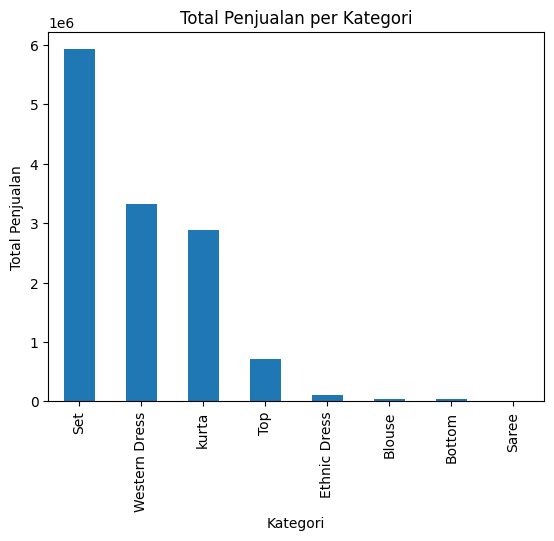

In [ ]:
# Visualisasi Penjualan per Kategori

import matplotlib.pyplot as plt

sales_per_category.plot(kind='bar')
plt.title('Total Penjualan per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Penjualan')
plt.show()

Grafik diatas menunjukkan total penjualan berdasarkan kategori produk. Terlihat bahwa kategori "Set" memiliki kontribusi penjualan tertinggi dibandingkan kategori lainnya, diikuti oleh "Western Dress" dan "Kurta".


#####**3. Analisis Berdasarkan Waktu (Bulan)**

In [ ]:
# Penjualan per Bulan

sales_per_month = df.groupby('month')['amount'].sum()
print(sales_per_month)

month
4      16615.0
5    7415300.0
6    5614903.0
Name: amount, dtype: float64


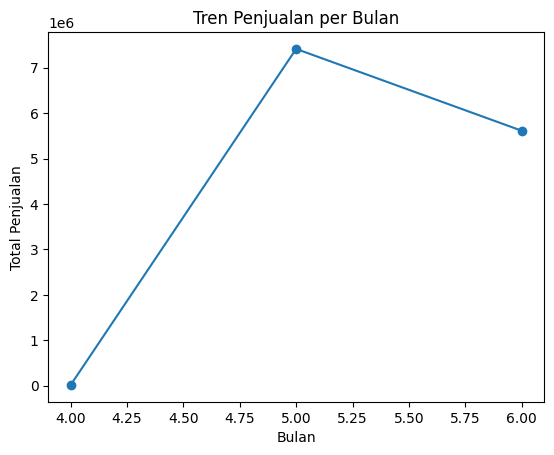

In [ ]:
# Visualisasi Tren Penjualan

sales_per_month.plot(kind='line', marker='o')
plt.title('Tren Penjualan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.show()

Grafik tren penjualan per bulan menunjukkan bahwa terjadi peningkatan signifikan pada bulan tertentu sebelum mengalami sedikit penurunan. Hal ini mengindikasikan adanya pola musiman dalam penjualan.


#####**4. Analisis Produk Terlaris**

In [ ]:
# Top 10 Produk Terlaris

top_product = df.groupby('sku')['qty'].sum().sort_values(ascending=False).head(10)
print(top_product)

sku
JNE3797-KR-L       397
JNE3797-KR-M       370
JNE3797-KR-S       272
JNE3797-KR-XL      263
SET183-KR-DH-M     177
JNE3797-KR-XXXL    152
JNE3797-KR-XXL     152
JNE3797-KR-XS      141
JNE3798-KR-XL       75
JNE3798-KR-M        68
Name: qty, dtype: int64


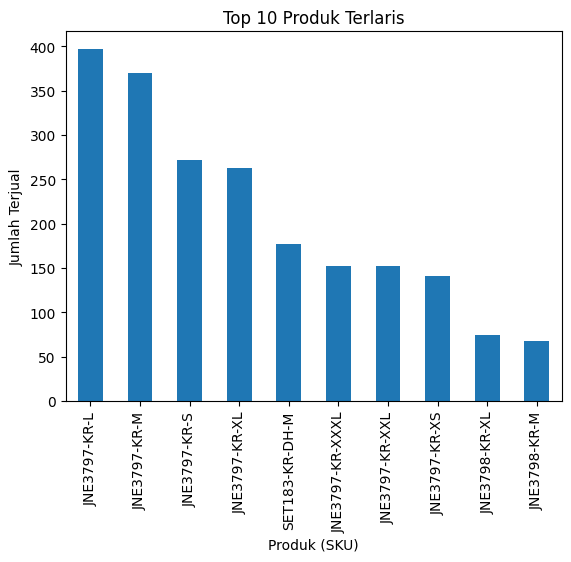

In [ ]:
# Visualisasi Produk Terlaris

top_product.plot(kind='bar')
plt.title('Top 10 Produk Terlaris')
plt.xlabel('Produk (SKU)')
plt.ylabel('Jumlah Terjual')
plt.show()

Berdasarkan analisis produk terlaris, beberapa SKU memiliki jumlah penjualan yang jauh lebih tinggi dibandingkan produk lainnya. Produk-produk ini dapat menjadi fokus utama dalam strategi pemasaran.


#####**5. Analisis Status Pengiriman**

In [ ]:
# Distribusi Status

df['status'].value_counts()

,count
status,
Shipped - Delivered to Buyer,16672
Shipped - Returned to Seller,1054
Shipped - Picked Up,967
Pending - Waiting for Pick Up,280
Pending,220
Shipped - Returning to Seller,143
Shipped - Out for Delivery,34
Shipped - Rejected by Buyer,5
Shipped - Lost in Transit,3


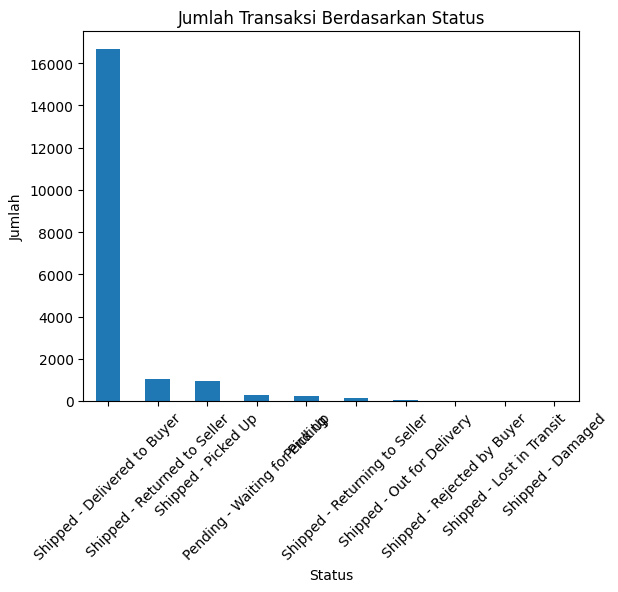

In [ ]:
# Visualisasi Status Transaksi

status_count = df['status'].value_counts()

status_count.plot(kind='bar')
plt.title('Jumlah Transaksi Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

Grafik ini menunjukkan distribusi status transaksi. Mayoritas pesanan berhasil dikirim (Shipped - Delivered to Buyer), namun terdapat juga sejumlah transaksi yang dikembalikan atau masih dalam proses, yang dapat menjadi bahan evaluasi dalam meningkatkan kualitas layanan.


#####**6. Penjualan Berdasarkan Kota**

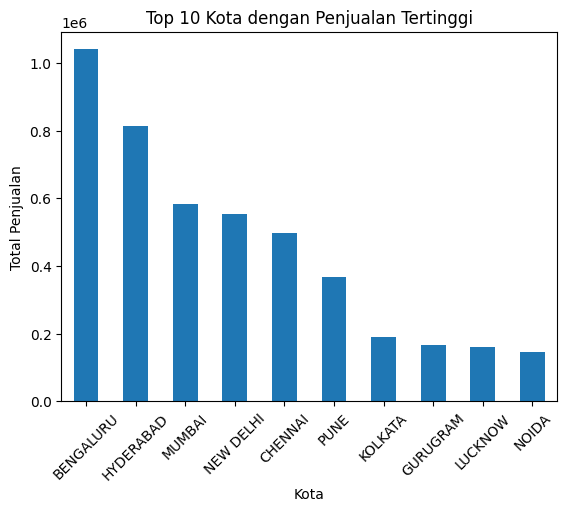

In [ ]:
# Analisis Penjualan Berdasarkan Kota
sales_city = df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10)

sales_city.plot(kind='bar')
plt.title('Top 10 Kota dengan Penjualan Tertinggi')
plt.xlabel('Kota')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.show()

Analisis ini menunjukkan kota-kota dengan kontribusi penjualan tertinggi. Informasi ini dapat digunakan untuk menentukan wilayah dengan potensi pasar terbesar serta sebagai dasar dalam strategi distribusi dan pemasaran.


#####**7. Rata-rata Nilai Transaksi**

In [ ]:
# Analisis Rata-Rata Transaksi

avg_sales = df['amount'].mean()
print("Rata-rata transaksi:", avg_sales)

Rata-rata transaksi: 673.2451622890758


Nilai rata-rata transaksi menunjukkan besaran pembelian pelanggan dalam satu transaksi. Informasi ini penting untuk memahami perilaku konsumen serta menentukan strategi penetapan harga dan promosi.


#####**8. Persentase Penjualan per Kategori**

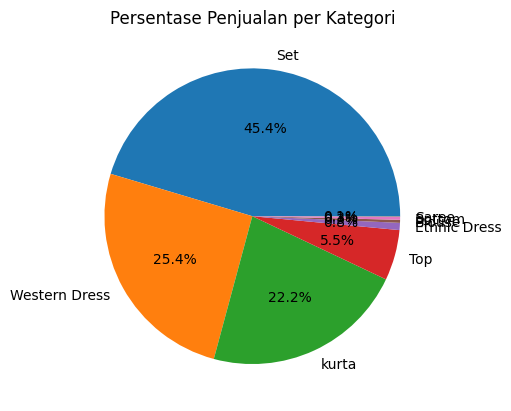

In [ ]:
# Pie Chart

sales_per_category.plot(kind='pie', autopct='%1.1f%%')
plt.title('Persentase Penjualan per Kategori')
plt.ylabel('')
plt.show()

Diagram pie menunjukkan proporsi kontribusi masing-masing kategori terhadap total penjualan. Terlihat bahwa beberapa kategori mendominasi penjualan secara keseluruhan.


#####**9. Penjualan Berdasarkan Status**

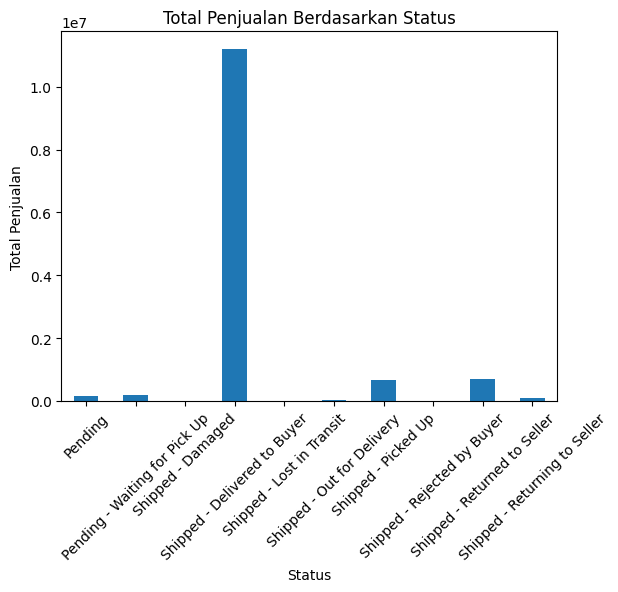

In [ ]:
# Analisis Status vs Penjualan

status_sales = df.groupby('status')['amount'].sum()

status_sales.plot(kind='bar')
plt.title('Total Penjualan Berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.show()

Analisis ini menunjukkan kontribusi nilai penjualan berdasarkan status transaksi. Hal ini membantu dalam memahami dampak dari pesanan yang berhasil maupun yang gagal terhadap total pendapatan.


####**Kesimpulan**

Berdasarkan hasil analisis yang telah dilakukan, dapat disimpulkan bahwa kategori produk tertentu memiliki kontribusi dominan terhadap total penjualan. Selain itu, terdapat pola tren penjualan berdasarkan waktu serta variasi performa antar produk. Analisis ini memberikan insight yang berguna bagi perusahaan dalam menentukan strategi pemasaran, pengelolaan produk, dan peningkatan layanan kepada pelanggan.
